In [1]:
# 데이터 로드 및 기본 정보 확인
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

plt.rcParams['font.family'] = 'Malgun Gothic'  # 그래프에 한글이 깨지지 않도록 폰트 설정 (Windows 기본 맑은 고딕)
plt.rcParams['axes.unicode_minus'] = False  # 한글 폰트 사용 시 마이너스(-) 기호 깨짐 방지

card_df = pd.read_csv('../data/creditcard.csv')
card_df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [2]:
# Time 컬럼 제거
# Time은 거래 발생 후 경과 초(0~172792)라 사기 여부와 인과관계가 약하고,
# 스케일링되지 않은 큰 범위 값이라 V1~V28(대부분 -1~1대) 옆에 같이 들어가면 로지스틱 회귀 최적화(수렴)에 방해가 됨.
# 실제 벤치마크(4-2 데이터 기준): Time 유지 시 AUC 0.9553(수렴 경고 발생) -> Time 제거 시 AUC 0.9744로 개선 확인.
# 이후 모든 실험(1~7단계, 튜닝, SMOTE 포함)은 Time이 제거된 데이터로 진행.
card_df = card_df.drop('Time', axis=1)
card_df.head(3)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [3]:
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.2f}'.format

In [4]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score


def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    f1 = f1_score(y_test,pred)
    # ROC-AUC 추가
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
    F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

In [5]:
card_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V1      284807 non-null  float64
 1   V2      284807 non-null  float64
 2   V3      284807 non-null  float64
 3   V4      284807 non-null  float64
 4   V5      284807 non-null  float64
 5   V6      284807 non-null  float64
 6   V7      284807 non-null  float64
 7   V8      284807 non-null  float64
 8   V9      284807 non-null  float64
 9   V10     284807 non-null  float64
 10  V11     284807 non-null  float64
 11  V12     284807 non-null  float64
 12  V13     284807 non-null  float64
 13  V14     284807 non-null  float64
 14  V15     284807 non-null  float64
 15  V16     284807 non-null  float64
 16  V17     284807 non-null  float64
 17  V18     284807 non-null  float64
 18  V19     284807 non-null  float64
 19  V20     284807 non-null  float64
 20  V21     284807 non-null  float64
 21  V22     284807 non-nu

In [6]:
card_df.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,284807.00,0.00,1.96,-56.41,-0.92,0.02,1.32,2.45
V2,284807.00,0.00,1.65,-72.72,-0.60,0.07,0.80,22.06
V3,284807.00,-0.00,1.52,-48.33,-0.89,0.18,1.03,9.38
V4,284807.00,0.00,1.42,-5.68,-0.85,-0.02,0.74,16.88
V5,284807.00,0.00,1.38,-113.74,-0.69,-0.05,0.61,34.80
V6,284807.00,0.00,1.33,-26.16,-0.77,-0.27,0.40,73.30
V7,284807.00,-0.00,1.24,-43.56,-0.55,0.04,0.57,120.59
V8,284807.00,0.00,1.19,-73.22,-0.21,0.02,0.33,20.01
V9,284807.00,-0.00,1.10,-13.43,-0.64,-0.05,0.60,15.59
V10,284807.00,0.00,1.09,-24.59,-0.54,-0.09,0.45,23.75


In [7]:
# 공통 함수 정의: 이상치 확인/제거, 중복행 제거, 스케일링, 로지스틱 회귀 학습+평가
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


def get_outlier(df, column, weight=1.5):
    fraud = df[df['Class'] == 1][column]  # 사기(Class=1) 건의 해당 컬럼 값만 추출
    q25 = np.percentile(fraud.values, 25)  # 1사분위수
    q75 = np.percentile(fraud.values, 75)  # 3사분위수
    iqr = (q75 - q25) * weight  # IQR에 가중치를 곱한 값
    lowest = q25 - iqr  # 하한
    highest = q75 + iqr  # 상한
    return fraud[(fraud < lowest) | (fraud > highest)].index  # 하한보다 작거나 상한보다 큰 값의 인덱스 반환


def remove_outliers(df):
    df_out = df.copy()  # 원본 보존을 위해 복사
    idx = get_outlier(df_out, 'V14', weight=1.5)  # V14 기준 이상치 인덱스 추출
    return df_out.drop(idx, axis=0)  # 이상치 행 제거


def remove_dup(df):
    return df.drop_duplicates().reset_index(drop=True)  # 중복행 제거 후 인덱스 재정렬


def scale_amount(df):
    df_s = df.copy()  # 원본 보존을 위해 복사
    df_s['Amount_Scaled'] = RobustScaler().fit_transform(df_s[['Amount']])  # Amount를 RobustScaler로 스케일링
    return df_s.drop('Amount', axis=1)  # 스케일링 전 원본 Amount 컬럼 삭제


def run_lr(df, name):
    X = df.drop('Class', axis=1)  # 피처
    y = df['Class']  # 레이블(사기 여부)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=0, stratify=y
    )  # 학습/테스트 분리 (모든 실험 동일 옵션 사용)
    model = LogisticRegression(max_iter=1000)  # 로지스틱 회귀 모델 생성
    model.fit(X_train, y_train)  # 학습
    pred = model.predict(X_test)  # 예측 클래스(0/1)
    proba = model.predict_proba(X_test)[:, 1]  # 사기(Class=1) 예측 확률
    print(f'--- {name} ---')
    get_clf_eval(y_test, pred, proba)  # 성능 평가 출력
    return {'model': model, 'pred': pred, 'proba': proba}

## 1. 원본 데이터 (전처리 없음)

In [8]:
# 1-1. 원본 그대로 (스케일링 X)
res_raw = run_lr(card_df, '원본(스케일링 X)')  # 이상치/중복행/Amount 모두 원본 그대로 사용

--- 원본(스케일링 X) ---
오차 행렬
[[56852    12]
 [   37    61]]
정확도: 0.9991, 정밀도: 0.8356, 재현율: 0.6224,    F1: 0.7135, AUC:0.9663


In [9]:
# 1-2. 원본 + 스케일링만 적용
df_raw_scaled = scale_amount(card_df)  # 이상치/중복행 제거 없이 Amount 스케일링만 적용
res_raw_scaled = run_lr(df_raw_scaled, '원본+스케일링')

--- 원본+스케일링 ---
오차 행렬
[[56853    11]
 [   35    63]]
정확도: 0.9992, 정밀도: 0.8514, 재현율: 0.6429,    F1: 0.7326, AUC:0.9689


## 2. 이상치만 제거 (중복행은 그대로)

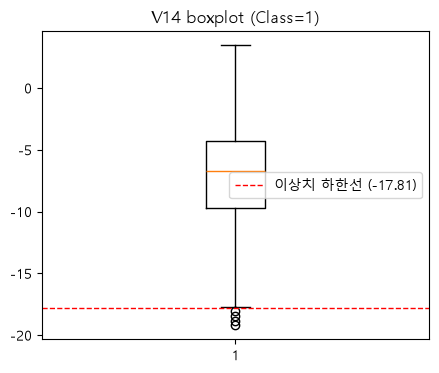

count   492.00
mean     -6.97
std       4.28
min     -19.21
25%      -9.69
50%      -6.73
75%      -4.28
max       3.44
Name: V14, dtype: float64
이상치 인덱스: [8296, 8615, 9035, 9252]
이상치 V14 값: [-19.2143254902614, -18.8220867423816, -18.4937733551053, -18.0499976898594]


In [10]:
# V14 이상치 시각적 확인 (사기 거래 기준)
fraud_v14 = card_df[card_df['Class'] == 1]['V14']  # 사기 거래(Class=1)의 V14 값만 추출
q25, q75 = fraud_v14.quantile(0.25), fraud_v14.quantile(0.75)  # 1사분위수, 3사분위수
lower_bound = q25 - 1.5 * (q75 - q25)  # 이상치 판정 하한선 (get_outlier와 동일한 기준: IQR*1.5)

plt.figure(figsize=(5, 4))
plt.boxplot(fraud_v14)  # 박스=IQR(25~75%), 가운데 선=중앙값, 수염 밖 점(o)=이상치
plt.axhline(lower_bound, color='red', linestyle='--', linewidth=1, label=f'이상치 하한선 ({lower_bound:.2f})')  # 하한선을 그래프에 표시
plt.title('V14 boxplot (Class=1)')
plt.legend()
plt.show()

print(fraud_v14.describe())  # 사기 거래 V14의 기초통계량 확인

outlier_idx = get_outlier(card_df, 'V14', weight=1.5)  # IQR 기준 이상치 인덱스 추출
print('이상치 인덱스:', outlier_idx.tolist())
print('이상치 V14 값:', card_df.loc[outlier_idx, 'V14'].tolist())  # 하한선보다 얼마나 벗어났는지 실제 값으로 확인

In [11]:
# 2-1. 이상치 제거 (스케일링 X)
df_out = remove_outliers(card_df)  # 이상치만 제거, 중복행/스케일링은 그대로
res_out = run_lr(df_out, '이상치제거(스케일링 X)')

--- 이상치제거(스케일링 X) ---
오차 행렬
[[56853    10]
 [   34    64]]
정확도: 0.9992, 정밀도: 0.8649, 재현율: 0.6531,    F1: 0.7442, AUC:0.9653


In [12]:
# 2-2. 이상치 제거 + 스케일링
df_out_scaled = scale_amount(df_out)  # 이상치 제거된 데이터에 스케일링 추가 적용
res_out_scaled = run_lr(df_out_scaled, '이상치제거+스케일링')

--- 이상치제거+스케일링 ---
오차 행렬
[[56853    10]
 [   33    65]]
정확도: 0.9992, 정밀도: 0.8667, 재현율: 0.6633,    F1: 0.7514, AUC:0.9665


## 3. 중복행만 제거 (이상치는 그대로)

In [13]:
# 중복행 확인
print('전체 행 수:', len(card_df))
print('중복행 수:', card_df.duplicated().sum())  # 완전히 동일한 행이 몇 개인지 확인

전체 행 수: 284807


중복행 수: 9144


In [14]:
# 3-1. 중복행 제거 (스케일링 X)
df_dup = remove_dup(card_df)  # 중복행만 제거, 이상치/스케일링은 그대로
res_dup = run_lr(df_dup, '중복제거(스케일링 X)')

--- 중복제거(스케일링 X) ---
오차 행렬
[[55027    11]
 [   38    57]]
정확도: 0.9991, 정밀도: 0.8382, 재현율: 0.6000,    F1: 0.6994, AUC:0.9654


In [15]:
# 3-2. 중복행 제거 + 스케일링
df_dup_scaled = scale_amount(df_dup)  # 중복행 제거된 데이터에 스케일링 추가 적용
res_dup_scaled = run_lr(df_dup_scaled, '중복제거+스케일링')

--- 중복제거+스케일링 ---
오차 행렬
[[55029     9]
 [   38    57]]
정확도: 0.9991, 정밀도: 0.8636, 재현율: 0.6000,    F1: 0.7081, AUC:0.9652


## 4. 이상치 + 중복행 모두 제거
※ 이상치·중복행은 위에서 이미 시각적으로 확인했으므로 바로 제거 후 진행.

In [16]:
# 4-1. 이상치+중복행 모두 제거 (스케일링 X)
df_both = remove_dup(remove_outliers(card_df))  # 이상치 제거 후 중복행까지 제거
res_both = run_lr(df_both, '이상치+중복제거(스케일링 X)')

--- 이상치+중복제거(스케일링 X) ---
오차 행렬
[[55027    11]
 [   37    57]]
정확도: 0.9991, 정밀도: 0.8382, 재현율: 0.6064,    F1: 0.7037, AUC:0.9643


In [17]:
# 4-2. 이상치+중복행 모두 제거 + 스케일링
df_both_scaled = scale_amount(df_both)  # 이상치+중복행 제거된 데이터에 스케일링 추가 적용
res_both_scaled = run_lr(df_both_scaled, '이상치+중복제거+스케일링')

--- 이상치+중복제거+스케일링 ---
오차 행렬
[[55027    11]
 [   36    58]]
정확도: 0.9991, 정밀도: 0.8406, 재현율: 0.6170,    F1: 0.7117, AUC:0.9628


## 결과 저장 (피클)

In [18]:
# 8개 실험 결과를 하나의 딕셔너리로 묶어 피클로 저장
import pickle

results = {
    'raw': res_raw,                    # 1-1. 원본
    'raw_scaled': res_raw_scaled,      # 1-2. 원본+스케일링
    'outlier': res_out,                # 2-1. 이상치제거
    'outlier_scaled': res_out_scaled,  # 2-2. 이상치제거+스케일링
    'dup': res_dup,                    # 3-1. 중복제거
    'dup_scaled': res_dup_scaled,      # 3-2. 중복제거+스케일링
    'both': res_both,                  # 4-1. 이상치+중복제거
    'both_scaled': res_both_scaled,    # 4-2. 이상치+중복제거+스케일링
}

with open('lr_clf_result.pkl', 'wb') as f:  # 바이너리 쓰기 모드로 파일 오픈
    pickle.dump(results, f)  # results 딕셔너리를 피클로 직렬화하여 저장

print('저장 완료: lr_clf_result.pkl')

저장 완료: lr_clf_result.pkl


## 5. 4-2 데이터로 하이퍼파라미터 튜닝 (AUC·F1 최적화)
이상치+중복행 제거 + 스케일링까지 적용한 `df_both_scaled`를 그대로 사용한다.
`GridSearchCV`로 C·penalty·class_weight를 탐색해 AUC를 최대화하고,
그 다음 예측 확률의 판정 임계값(threshold)을 별도로 튜닝해 F1까지 끌어올린다.

In [19]:
# 5-1. GridSearchCV로 AUC 기준 최적 하이퍼파라미터 탐색
from sklearn.model_selection import GridSearchCV

X_tune = df_both_scaled.drop('Class', axis=1)  # 4-2 데이터의 피처
y_tune = df_both_scaled['Class']  # 4-2 데이터의 레이블(사기 여부)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_tune, y_tune, test_size=0.2, random_state=0, stratify=y_tune
)  # 기존 실험들과 동일한 분리 옵션

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],        # 규제 강도 (작을수록 규제가 강함)
    'penalty': ['l1', 'l2'],              # 규제 방식
    'class_weight': [None, 'balanced'],   # 클래스 불균형 보정 여부 (사기 비율 0.17%라 효과가 클 수 있음)
}

grid = GridSearchCV(
    LogisticRegression(solver='liblinear', max_iter=1000),  # l1/l2 규제를 모두 지원하는 solver
    param_grid,
    scoring='roc_auc',  # AUC를 기준으로 최적 조합 탐색
    cv=5,                # 5-fold 교차검증
    n_jobs=-1,            # 가용 CPU 코어를 모두 사용해 병렬 탐색
)
grid.fit(X_tr, y_tr)  # 학습 데이터에서만 탐색 (테스트셋은 아직 손대지 않음)

print('베스트 파라미터:', grid.best_params_)
print('베스트 CV AUC:', round(grid.best_score_, 4))

베스트 파라미터: {'C': 0.1, 'class_weight': None, 'penalty': 'l1'}
베스트 CV AUC: 0.979


In [20]:
# 5-2. 튜닝된 모델을 테스트셋에 적용 (기본 임계값 0.5)
best_model = grid.best_estimator_  # GridSearchCV가 전체 학습 데이터로 재학습해둔 최적 모델
proba_te = best_model.predict_proba(X_te)[:, 1]  # 테스트셋 사기 예측 확률
pred_te = best_model.predict(X_te)  # 기본 임계값(0.5) 기준 예측 클래스

print('--- 튜닝 모델 (threshold=0.5) ---')
get_clf_eval(y_te, pred_te, proba_te)

--- 튜닝 모델 (threshold=0.5) ---
오차 행렬
[[55027    11]
 [   38    56]]
정확도: 0.9991, 정밀도: 0.8358, 재현율: 0.5957,    F1: 0.6957, AUC:0.9683


In [21]:
# 5-3. F1을 최대화하는 임계값 탐색 (학습 데이터의 교차검증 예측확률만 사용, 테스트셋은 건드리지 않음)
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

oof_proba = cross_val_predict(
    best_model, X_tr, y_tr, cv=5, method='predict_proba', n_jobs=-1
)[:, 1]  # 학습 데이터 각 행에 대한 out-of-fold 예측 확률 (자기 자신을 학습에 쓰지 않은 예측)

precisions, recalls, thresholds = precision_recall_curve(y_tr, oof_proba)  # 임계값별 정밀도/재현율
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-12)  # 임계값별 F1 계산
best_idx = f1s[:-1].argmax()  # precision_recall_curve는 thresholds가 precisions/recalls보다 1개 적음
best_threshold = thresholds[best_idx]  # F1이 가장 높은 임계값

print(f'F1 최적 임계값: {best_threshold:.4f} (교차검증 F1={f1s[best_idx]:.4f})')

F1 최적 임계값: 0.0769 (교차검증 F1=0.7979)


In [22]:
# 5-4. 튜닝된 임계값을 테스트셋에 적용해 최종 평가
pred_tuned = (proba_te >= best_threshold).astype(int)  # 확률이 튜닝된 임계값 이상이면 사기(1)로 판정

print('--- 튜닝 모델 (threshold 최적화) ---')
get_clf_eval(y_te, pred_tuned, proba_te)

res_tuned = {
    'model': best_model,
    'pred': pred_tuned,
    'proba': proba_te,
    'threshold': best_threshold,
    'params': grid.best_params_,
}

--- 튜닝 모델 (threshold 최적화) ---
오차 행렬
[[55013    25]
 [   23    71]]
정확도: 0.9991, 정밀도: 0.7396, 재현율: 0.7553,    F1: 0.7474, AUC:0.9683


In [23]:
# 튜닝 결과까지 포함해서 피클 다시 저장
results['tuned_4_2'] = res_tuned  # 4-2 데이터 + 하이퍼파라미터/임계값 튜닝 결과 추가

with open('lr_clf_result.pkl', 'wb') as f:
    pickle.dump(results, f)

print('저장 완료: lr_clf_result.pkl (튜닝 결과 포함)')

저장 완료: lr_clf_result.pkl (튜닝 결과 포함)


## 6. Hyperopt(TPE)로 하이퍼파라미터 재탐색
GridSearchCV는 격자 위 모든 조합을 다 시도하는 전수 탐색이다. Hyperopt는 지금까지의 시도 결과를 바탕으로
다음에 시도할 조합을 베이지안 방식(TPE)으로 골라, 같은 데이터·같은 탐색 범위에서 GridSearchCV와
결과를 비교한다.

In [24]:
# 6-1. Hyperopt(TPE)로 C·penalty·class_weight 재탐색 (GridSearchCV와 동일한 데이터·범위로 비교)
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK, space_eval
from sklearn.model_selection import cross_val_score

space = {
    'C': hp.loguniform('C', np.log(0.01), np.log(100)),           # GridSearchCV의 0.01~100 범위와 동일한 로그스케일 연속값
    'penalty': hp.choice('penalty', ['l1', 'l2']),                  # 규제 방식
    'class_weight': hp.choice('class_weight', [None, 'balanced']),  # 클래스 불균형 보정 여부
}

def objective(params):
    clf = LogisticRegression(solver='liblinear', max_iter=1000, **params)  # GridSearchCV와 동일 설정
    auc = cross_val_score(clf, X_tr, y_tr, cv=3, scoring='roc_auc', n_jobs=-1).mean()  # 3-fold CV 평균 AUC
    return {'loss': -auc, 'status': STATUS_OK}  # hyperopt는 손실을 최소화하므로 AUC에 음수를 취함

trials = Trials()
best_raw = fmin(
    objective, space, algo=tpe.suggest, max_evals=15, trials=trials,
    rstate=np.random.default_rng(0),  # 재현 가능한 결과를 위한 시드
)
best_params_hopt = space_eval(space, best_raw)  # 인덱스로 나온 결과를 실제 파라미터 값으로 변환

print('Hyperopt 베스트 파라미터:', best_params_hopt)
print('Hyperopt 베스트 CV AUC:', round(-min(t['result']['loss'] for t in trials.trials), 4))


  0%|          | 0/15 [00:00<?, ?trial/s, best loss=?]


  7%|▋         | 1/15 [00:33<07:45, 33.26s/trial, best loss: -0.9713099313201788]


 13%|█▎        | 2/15 [01:29<10:06, 46.62s/trial, best loss: -0.9713099313201788]


 20%|██        | 3/15 [01:34<05:30, 27.54s/trial, best loss: -0.9761385224753806]


 27%|██▋       | 4/15 [02:35<07:28, 40.74s/trial, best loss: -0.9761385224753806]

...


 87%|████████▋ | 13/15 [10:48<01:33, 46.51s/trial, best loss: -0.9770732221374324]


 93%|█████████▎| 14/15 [10:53<00:33, 33.93s/trial, best loss: -0.9770732221374324]


100%|██████████| 15/15 [13:15<00:00, 66.65s/trial, best loss: -0.9770732221374324]


100%|██████████| 15/15 [13:15<00:00, 53.04s/trial, best loss: -0.9770732221374324]


Hyperopt 베스트 파라미터: {'C': 0.8782859667426148, 'class_weight': None, 'penalty': 'l2'}
Hyperopt 베스트 CV AUC: 0.9771


In [25]:
# 6-2. Hyperopt가 찾은 최적 파라미터로 재학습 후 테스트셋 평가 (threshold=0.5)
best_model_hopt = LogisticRegression(solver='liblinear', max_iter=1000, **best_params_hopt)
best_model_hopt.fit(X_tr, y_tr)

proba_te_hopt = best_model_hopt.predict_proba(X_te)[:, 1]  # 테스트셋 사기 예측 확률
pred_te_hopt = best_model_hopt.predict(X_te)  # 기본 임계값(0.5) 기준 예측 클래스

print('--- Hyperopt 튜닝 모델 (threshold=0.5) ---')
get_clf_eval(y_te, pred_te_hopt, proba_te_hopt)

--- Hyperopt 튜닝 모델 (threshold=0.5) ---
오차 행렬
[[55027    11]
 [   38    56]]
정확도: 0.9991, 정밀도: 0.8358, 재현율: 0.5957,    F1: 0.6957, AUC:0.9606


In [26]:
# 6-3. Hyperopt 모델도 동일한 방식으로 F1 최적 임계값 탐색 후 최종 평가
oof_proba_hopt = cross_val_predict(
    best_model_hopt, X_tr, y_tr, cv=5, method='predict_proba', n_jobs=-1
)[:, 1]  # 학습 데이터 out-of-fold 예측 확률 (테스트셋은 사용하지 않음)

precisions_h, recalls_h, thresholds_h = precision_recall_curve(y_tr, oof_proba_hopt)
f1s_h = 2 * precisions_h * recalls_h / (precisions_h + recalls_h + 1e-12)
best_idx_h = f1s_h[:-1].argmax()
best_threshold_hopt = thresholds_h[best_idx_h]  # F1이 가장 높은 임계값

print(f'Hyperopt 모델 F1 최적 임계값: {best_threshold_hopt:.4f} (교차검증 F1={f1s_h[best_idx_h]:.4f})')

pred_tuned_hopt = (proba_te_hopt >= best_threshold_hopt).astype(int)  # 튜닝된 임계값을 테스트셋에 적용
print('--- Hyperopt 튜닝 모델 (threshold 최적화) ---')
get_clf_eval(y_te, pred_tuned_hopt, proba_te_hopt)

res_tuned_hopt = {
    'model': best_model_hopt,
    'pred': pred_tuned_hopt,
    'proba': proba_te_hopt,
    'threshold': best_threshold_hopt,
    'params': best_params_hopt,
}

Hyperopt 모델 F1 최적 임계값: 0.1110 (교차검증 F1=0.7892)
--- Hyperopt 튜닝 모델 (threshold 최적화) ---
오차 행렬
[[55015    23]
 [   24    70]]
정확도: 0.9991, 정밀도: 0.7527, 재현율: 0.7447,    F1: 0.7487, AUC:0.9606


In [27]:
# 6-4. GridSearchCV vs Hyperopt 비교 + 피클 저장
print('GridSearchCV :', grid.best_params_, '| test AUC', round(roc_auc_score(y_te, proba_te), 4), '| tuned F1', round(f1_score(y_te, pred_tuned), 4))
print('Hyperopt     :', best_params_hopt, '| test AUC', round(roc_auc_score(y_te, proba_te_hopt), 4), '| tuned F1', round(f1_score(y_te, pred_tuned_hopt), 4))

results['tuned_4_2_hyperopt'] = res_tuned_hopt  # Hyperopt로 튜닝한 결과 추가

with open('lr_clf_result.pkl', 'wb') as f:
    pickle.dump(results, f)

print('저장 완료: lr_clf_result.pkl (Hyperopt 결과 포함)')

GridSearchCV : {'C': 0.1, 'class_weight': None, 'penalty': 'l1'} | test AUC 0.9683 | tuned F1 0.7474
Hyperopt     : {'C': 0.8782859667426148, 'class_weight': None, 'penalty': 'l2'} | test AUC 0.9606 | tuned F1 0.7487
저장 완료: lr_clf_result.pkl (Hyperopt 결과 포함)


## 7. Hyperopt 베스트 파라미터 + SMOTE
Hyperopt가 찾은 `best_params_hopt`(C=0.0249, class_weight='balanced', penalty='l1')는 그대로 두고,
학습 데이터에만 SMOTE로 소수 클래스(사기)를 오버샘플링해서 같은 4-2 데이터에서 결과가 어떻게 달라지는지 확인한다.
테스트셋은 원본 그대로 유지해 왜곡 없이 평가한다.

In [28]:
# 7-1. Hyperopt 베스트 파라미터로 SMOTE 적용 데이터 학습 (SMOTE는 학습 데이터에만 적용)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=0)
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)  # 학습 데이터만 오버샘플링, 테스트셋은 원본 그대로 유지

print('SMOTE 적용 전 학습 데이터 클래스 분포:', y_tr.value_counts().to_dict())
print('SMOTE 적용 후 학습 데이터 클래스 분포:', y_tr_sm.value_counts().to_dict())

model_smote = LogisticRegression(solver='liblinear', max_iter=1000, **best_params_hopt)  # Hyperopt 베스트 파라미터 그대로 사용
model_smote.fit(X_tr_sm, y_tr_sm)  # SMOTE로 균형 맞춘 데이터로 학습

proba_te_smote = model_smote.predict_proba(X_te)[:, 1]  # 테스트셋(원본, 미변형)에 대한 예측 확률
pred_te_smote = model_smote.predict(X_te)  # 기본 임계값(0.5) 기준 예측 클래스

print('--- Hyperopt 베스트 파라미터 + SMOTE (threshold=0.5) ---')
get_clf_eval(y_te, pred_te_smote, proba_te_smote)

SMOTE 적용 전 학습 데이터 클래스 분포: {0: 220152, 1: 375}
SMOTE 적용 후 학습 데이터 클래스 분포: {0: 220152, 1: 220152}


--- Hyperopt 베스트 파라미터 + SMOTE (threshold=0.5) ---
오차 행렬
[[53809  1229]
 [   13    81]]
정확도: 0.9775, 정밀도: 0.0618, 재현율: 0.8617,    F1: 0.1154, AUC:0.9663


In [29]:
# 7-2. F1 최적 임계값 탐색 (SMOTE를 fold 안에서만 적용해 데이터 누수 방지) 후 테스트셋 최종 평가
from imblearn.pipeline import Pipeline as ImbPipeline

smote_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=0)),
    ('clf', LogisticRegression(solver='liblinear', max_iter=1000, **best_params_hopt)),
])  # 파이프라인으로 묶어야 교차검증 각 fold 안에서만 SMOTE가 적용되어 검증 폴드로의 누수를 막을 수 있음

oof_proba_smote = cross_val_predict(
    smote_pipe, X_tr, y_tr, cv=5, method='predict_proba', n_jobs=-1
)[:, 1]  # 원본(오버샘플링 전) 학습 데이터 기준 out-of-fold 예측 확률

precisions_s, recalls_s, thresholds_s = precision_recall_curve(y_tr, oof_proba_smote)
f1s_s = 2 * precisions_s * recalls_s / (precisions_s + recalls_s + 1e-12)
best_idx_s = f1s_s[:-1].argmax()
best_threshold_smote = thresholds_s[best_idx_s]  # F1이 가장 높은 임계값

print(f'SMOTE 모델 F1 최적 임계값: {best_threshold_smote:.4f} (교차검증 F1={f1s_s[best_idx_s]:.4f})')

pred_tuned_smote = (proba_te_smote >= best_threshold_smote).astype(int)  # 튜닝된 임계값을 테스트셋에 적용
print('--- Hyperopt 베스트 파라미터 + SMOTE (threshold 최적화) ---')
get_clf_eval(y_te, pred_tuned_smote, proba_te_smote)

res_smote = {
    'model': model_smote,
    'pred': pred_tuned_smote,
    'proba': proba_te_smote,
    'threshold': best_threshold_smote,
    'params': best_params_hopt,
}

SMOTE 모델 F1 최적 임계값: 1.0000 (교차검증 F1=0.7967)
--- Hyperopt 베스트 파라미터 + SMOTE (threshold 최적화) ---
오차 행렬
[[55025    13]
 [   26    68]]
정확도: 0.9993, 정밀도: 0.8395, 재현율: 0.7234,    F1: 0.7771, AUC:0.9663


In [30]:
# 7-3. Hyperopt(SMOTE 없음) vs Hyperopt+SMOTE 비교 + 피클 저장
print('Hyperopt         :', best_params_hopt, '| test AUC', round(roc_auc_score(y_te, proba_te_hopt), 4), '| tuned F1', round(f1_score(y_te, pred_tuned_hopt), 4))
print('Hyperopt + SMOTE :', best_params_hopt, '| test AUC', round(roc_auc_score(y_te, proba_te_smote), 4), '| tuned F1', round(f1_score(y_te, pred_tuned_smote), 4))

results['tuned_4_2_hyperopt_smote'] = res_smote  # Hyperopt 베스트 파라미터 + SMOTE 결과 추가

with open('lr_clf_result.pkl', 'wb') as f:
    pickle.dump(results, f)

print('저장 완료: lr_clf_result.pkl (SMOTE 결과 포함)')

Hyperopt         : {'C': 0.8782859667426148, 'class_weight': None, 'penalty': 'l2'} | test AUC 0.9606 | tuned F1 0.7487
Hyperopt + SMOTE : {'C': 0.8782859667426148, 'class_weight': None, 'penalty': 'l2'} | test AUC 0.9663 | tuned F1 0.7771
저장 완료: lr_clf_result.pkl (SMOTE 결과 포함)
